✅ Dataset chargé : 30000 lignes, 24 colonnes
✅ Nouvelles variables créées !


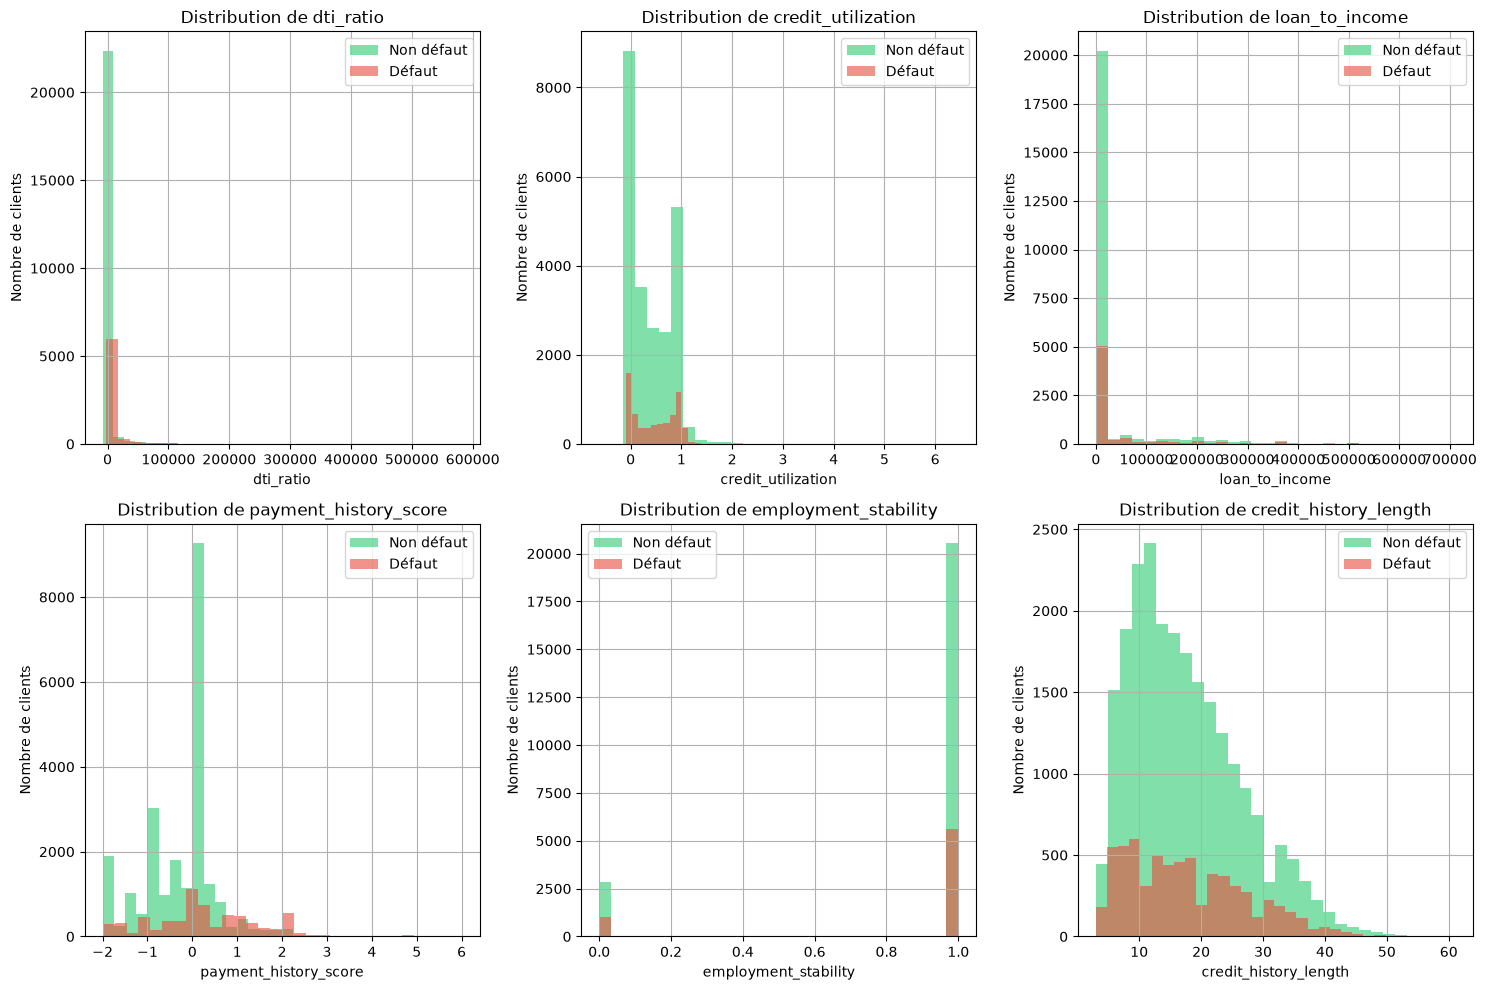


=== STATISTIQUES DES NOUVELLES VARIABLES ===
           dti_ratio  credit_utilization  loan_to_income  \
count   30000.000000        30000.000000    30000.000000   
mean     3788.042941            0.423764    28174.452587   
std     22027.557338            0.411454    79338.579385   
min     -8187.000000           -0.619890        0.384002   
25%         1.561719            0.022031       22.194274   
50%        13.417842            0.313991       39.980010   
75%        25.717318            0.829821      204.603581   
max    581775.000000            6.454977   710000.000000   

       payment_history_score  employment_stability  credit_history_length  
count           30000.000000          30000.000000           30000.000000  
mean               -0.182439              0.870967              17.485500  
std                 0.982176              0.335242               9.217904  
min                -2.000000              0.000000               3.000000  
25%                -0.833333     

In [1]:
# %% [markdown]
# # 03 - Feature Engineering
# ## Projet : AI Credit Risk Prediction Platform
# ## Dataset : UCI Default of Credit Card Clients

# %% [markdown]
# ### 1. Import et chargement des données

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement des données nettoyées
df = pd.read_csv('data/processed/credit_data_clean.csv') 
print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# %% [markdown]
# ### 2. Création des nouvelles variables

# %%
# 2.1 Debt-to-Income Ratio (approximé)
# DTI = Montant des factures / Remboursements (approximation)
df['dti_ratio'] = df['BILL_AMT1'] / (df['PAY_AMT1'] + 1)  # +1 pour éviter division par zéro

# 2.2 Credit Utilization (utilisation du crédit)
df['credit_utilization'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 2.3 Loan-to-Income Ratio (approximé)
df['loan_to_income'] = df['LIMIT_BAL'] / (df['PAY_AMT1'] + 1)

# 2.4 Payment History Score (moyenne des retards sur 6 mois)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['payment_history_score'] = df[pay_cols].mean(axis=1)

# 2.5 Employment Stability (approximé par l'âge)
df['employment_stability'] = np.where(df['AGE'] > 25, 1, 0)

# 2.6 Credit History Length (approximé par l'âge - 18)
df['credit_history_length'] = df['AGE'] - 18

# 2.7 Age Group (déjà créé en EDA, on le garde)
age_bins = [18, 25, 35, 45, 55, 65, 80]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

print("✅ Nouvelles variables créées !")

# %% [markdown]
# ### 3. Visualisation des nouvelles variables par rapport au défaut

# %%
new_features = ['dti_ratio', 'credit_utilization', 'loan_to_income', 
                'payment_history_score', 'employment_stability', 
                'credit_history_length']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feat in enumerate(new_features):
    for default in [0, 1]:
        label = 'Non défaut' if default == 0 else 'Défaut'
        color = '#2ecc71' if default == 0 else '#e74c3c'
        df[df['default'] == default][feat].hist(bins=30, alpha=0.6, 
                                                 label=label, color=color, ax=axes[idx])
    axes[idx].set_title(f'Distribution de {feat}')
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Nombre de clients')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../data/processed/new_features_distribution.png', dpi=150)
plt.show()

# %% [markdown]
# ### 4. Statistiques des nouvelles variables

# %%
print("\n=== STATISTIQUES DES NOUVELLES VARIABLES ===")
print(df[new_features].describe())

# %% [markdown]
# ### 5. Préparation pour la modélisation

# %%
# Séparer les features et la cible
# Variables numériques (on exclut les catégorielles pour l'instant)
features_numeriques = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 
                       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 
                       'PAY_AMT5', 'PAY_AMT6', 
                       'dti_ratio', 'credit_utilization', 'loan_to_income',
                       'payment_history_score', 'employment_stability', 
                       'credit_history_length']

features_categorielles = ['SEX', 'EDUCATION', 'MARRIAGE', 'age_group']

# Création du jeu de données final
X = df[features_numeriques + features_categorielles]
y = df['default']

# Encodage des variables catégorielles (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=features_categorielles, drop_first=True)

print(f"✅ Nombre de features final : {X_encoded.shape[1]}")
print(f"✅ Nombre d'échantillons : {X_encoded.shape[0]}")

# %% [markdown]
# ### 6. Sauvegarde des données préparées

# %%
import os
os.makedirs('../data/processed', exist_ok=True)

X_encoded.to_csv('../data/processed/X_features.csv', index=False)
y.to_csv('../data/processed/y_target.csv', index=False)

# Sauvegarder aussi la liste des features
feature_names = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Type': X_encoded.dtypes.astype(str)
})
feature_names.to_csv('../data/processed/feature_names.csv', index=False)

print("✅ Features et cible sauvegardées !")
print(f"✅ Shape final : X={X_encoded.shape}, y={y.shape}")

# %% [markdown]
# ### 7. Vérification du déséquilibre

# %%
print("\n=== DÉSÉQUILIBRE DES CLASSES ===")
print(f"Nombre de non-défauts : {sum(y==0)}")
print(f"Nombre de défauts : {sum(y==1)}")
print(f"Taux de défaut : {y.mean()*100:.2f}%")